# Explore Sacchi's Taheda Island Obs Datasets (Aug 22-27, 2024)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr

In [2]:
with xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc') as mesh:
    tmask = mesh.tmask
    mbathy = mesh.mbathy
    long = mesh.nav_lon
    latg = mesh.nav_lat

In [8]:
obs_dir = Path("/ocean/atall/MOAD/Obs/TaxedaIslandFromSacchi/")
#obs_file = obs_dir / "SalishSeaO2.csv"
obs_file = obs_dir / "SalishSeaO2_v2.csv"


In [9]:
obs_ds = pd.read_csv(obs_file, encoding='unicode_escape')
obs_ds = obs_ds.rename(columns={"Var1": "Datetime(UTC)", "Var2": "Lat", "Var3": "Long", "Var4": "O2_conc(µM)",
                                "Var5": "SST", "Var6": "Sal", "Var7": "Chl", "Var8": "POC", "Var9": "Chlf", "Var10": "O2_corr",})
obs_ds

,Datetime(UTC),Lat,Long,O2_conc(µM),SST,Sal,Chl,POC,Chlf,O2_corr
0,22-Aug-2024 19:13:00,49.841409,-124.827269,299.749583,19.009546,27.373192,1.453357,179.620148,35.118014,254.716344
1,22-Aug-2024 19:14:00,49.839449,-124.824778,299.856625,19.010492,27.378904,1.464000,178.615405,34.139813,254.798928
2,22-Aug-2024 19:15:00,49.837493,-124.822271,299.903750,19.010379,27.391567,1.460349,179.362636,33.203086,254.819719
3,22-Aug-2024 19:16:00,49.835539,-124.819768,299.849042,19.012642,27.394933,1.465396,179.919228,33.016190,254.768827
4,22-Aug-2024 19:17:00,49.833578,-124.817254,299.842917,19.015750,27.394950,1.448863,180.094488,33.537481,254.764560
...,...,...,...,...,...,...,...,...,...,...
4096,25-Aug-2024 16:28:00,49.726771,-124.679945,307.820875,18.239750,26.793950,1.461676,149.219870,23.236765,262.237640
4097,25-Aug-2024 16:29:00,49.726770,-124.679900,307.921375,18.251750,26.794442,1.459061,148.166100,22.931150,262.326267
4098,25-Aug-2024 16:30:00,49.726787,-124.679849,307.947792,18.263954,26.794633,1.443396,147.545611,22.709287,262.352316
4099,25-Aug-2024 16:31:00,49.726799,-124.679818,307.875708,18.274467,26.797629,1.451001,148.420136,22.487854,262.289511


/tmp/ipykernel_2638887/4005082735.py:2: UserWarning: linewidths is ignored by contourf
  ax.contourf(long, latg, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='whitesmoke')


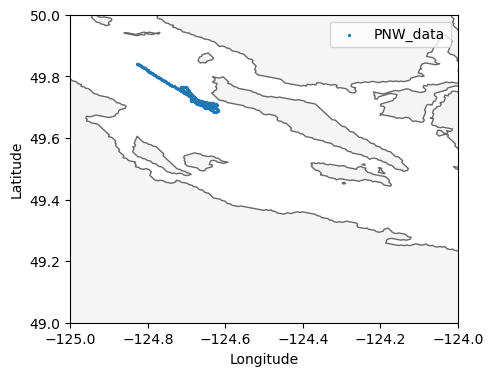

In [10]:
fig, ax = plt.subplots(1,1,figsize=(5, 4))
ax.contourf(long, latg, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(long, latg, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')
ax.set_ylim([49,50])
ax.set_xlim([-125,-124])
# plot the location of observations
ax.scatter(obs_ds.Long, obs_ds.Lat, s=2, label="PNW_data")
ax.legend()
plt.show()

The data are not at the same location; depth is being added to prepare for matching.

In [34]:
obs_ds['Z']=2
obs_ds['dtUTC'] = pd.to_datetime(obs_ds['Datetime(UTC)']).dt.strftime('%Y-%m-%dT%H:%M:%S')

In [35]:
obs_ds

,Datetime(UTC),Lat,Long,O2_conc(µM),SST,Sal,Chl,POC,Chlf,O2_corr,Z,dtUTC
0,22-Aug-2024 19:13:00,49.841409,-124.827269,299.749583,19.009546,27.373192,1.453357,179.620148,35.118014,254.716344,2,2024-08-22T19:13:00
1,22-Aug-2024 19:14:00,49.839449,-124.824778,299.856625,19.010492,27.378904,1.464000,178.615405,34.139813,254.798928,2,2024-08-22T19:14:00
2,22-Aug-2024 19:15:00,49.837493,-124.822271,299.903750,19.010379,27.391567,1.460349,179.362636,33.203086,254.819719,2,2024-08-22T19:15:00
3,22-Aug-2024 19:16:00,49.835539,-124.819768,299.849042,19.012642,27.394933,1.465396,179.919228,33.016190,254.768827,2,2024-08-22T19:16:00
4,22-Aug-2024 19:17:00,49.833578,-124.817254,299.842917,19.015750,27.394950,1.448863,180.094488,33.537481,254.764560,2,2024-08-22T19:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...
4096,25-Aug-2024 16:28:00,49.726771,-124.679945,307.820875,18.239750,26.793950,1.461676,149.219870,23.236765,262.237640,2,2024-08-25T16:28:00
4097,25-Aug-2024 16:29:00,49.726770,-124.679900,307.921375,18.251750,26.794442,1.459061,148.166100,22.931150,262.326267,2,2024-08-25T16:29:00
4098,25-Aug-2024 16:30:00,49.726787,-124.679849,307.947792,18.263954,26.794633,1.443396,147.545611,22.709287,262.352316,2,2024-08-25T16:30:00
4099,25-Aug-2024 16:31:00,49.726799,-124.679818,307.875708,18.274467,26.797629,1.451001,148.420136,22.487854,262.289511,2,2024-08-25T16:31:00


In [36]:
#obs_ds.to_csv('/ocean/atall/MOAD/Obs/TaxedaIslandFromSacchi/SalishSeaO2_TallFor Matching.csv')
obs_ds.to_csv('/ocean/atall/MOAD/Obs/TaxedaIslandFromSacchi/SalishSeaO2_v2_2m_TallFor Matching.csv')

Now from the terminal: python3 comparison_script.py ObsModel_202111_hourlyPPrunAug24.yaml from_sacchi 2024 Sacchi

## Plot figures

In [37]:
def calc_stats(x, y):
    stats = {}
    MSE = np.mean((y - x)**2)
    stats['RMSE'] = np.sqrt(MSE)
    stats['bias'] = np.mean(y) - np.mean(x)
    stats['WSS'] = 1 - MSE / np.mean((abs(y - np.mean(x)) + abs(x - np.mean(x)))**2)
    
    return stats


def plot_panel(ax, x, y, lims, units):
    stats = calc_stats(x, y)

    statstext = f"RMSE = {stats['RMSE']:.3f} {units}\nbias = {stats['bias']:.3f} {units}\nWSS = {stats['WSS']:.3f}"
    
    props = dict(boxstyle='round', facecolor='w', alpha=0.9)
    c = ax.text(0.01, 0.8, statstext, bbox=props, transform=ax.transAxes, fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    return c

In [38]:
df05 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_from_sacchi_20240822_20240827_05m.csv')
df5 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_from_sacchi_20240822_20240827_5m.csv')
df = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_from_sacchi_20240822_20240827.csv')
df

,Unnamed: 0.1,Unnamed: 0,Datetime(UTC),Lat,Lon,O2_conc(µM),SST,Sal,Chl,POC,...,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_total_alkalinity,mod_dissolved_inorganic_carbon,mod_dissolved_oxygen,k
0,0,0,22-Aug-2024 19:13:00,49.841409,-124.827269,299.749583,19.009546,27.373192,1.453357,179.620148,...,44.551708,1.952190,0.353524,0.640582,28.671843,14.597730,2067.711914,1935.812988,243.993805,1
1,1,1,22-Aug-2024 19:14:00,49.839449,-124.824778,299.856625,19.010492,27.378904,1.464000,178.615405,...,44.551708,1.952190,0.353524,0.640582,28.671843,14.597730,2067.711914,1935.812988,243.993805,1
2,2,2,22-Aug-2024 19:15:00,49.837493,-124.822271,299.903750,19.010379,27.391567,1.460349,179.362636,...,44.438614,1.963965,0.347796,0.648546,28.657648,14.676029,2067.245605,1934.091309,244.289536,1
3,3,3,22-Aug-2024 19:16:00,49.835539,-124.819768,299.849042,19.012642,27.394933,1.465396,179.919228,...,44.438614,1.963965,0.347796,0.648546,28.657648,14.676029,2067.245605,1934.091309,244.289536,1
4,4,4,22-Aug-2024 19:17:00,49.833578,-124.817254,299.842917,19.015750,27.394950,1.448863,180.094488,...,44.342350,1.973509,0.343750,0.654646,28.644587,14.744968,2066.884521,1932.633789,244.588013,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4096,4096,4096,25-Aug-2024 16:28:00,49.726771,-124.679945,307.820875,18.239750,26.793950,1.461676,149.219870,...,37.565979,2.086241,0.104647,0.490951,27.802986,18.217918,2039.697266,1845.100830,251.381073,1
4097,4097,4097,25-Aug-2024 16:29:00,49.726770,-124.679900,307.921375,18.251750,26.794442,1.459061,148.166100,...,37.565979,2.086241,0.104647,0.490951,27.802986,18.217918,2039.697266,1845.100830,251.381073,1
4098,4098,4098,25-Aug-2024 16:30:00,49.726787,-124.679849,307.947792,18.263954,26.794633,1.443396,147.545611,...,37.565979,2.086241,0.104647,0.490951,27.802986,18.217918,2039.697266,1845.100830,251.381073,1
4099,4099,4099,25-Aug-2024 16:31:00,49.726799,-124.679818,307.875708,18.274467,26.797629,1.451001,148.420136,...,37.565979,2.086241,0.104647,0.490951,27.802986,18.217918,2039.697266,1845.100830,251.381073,1


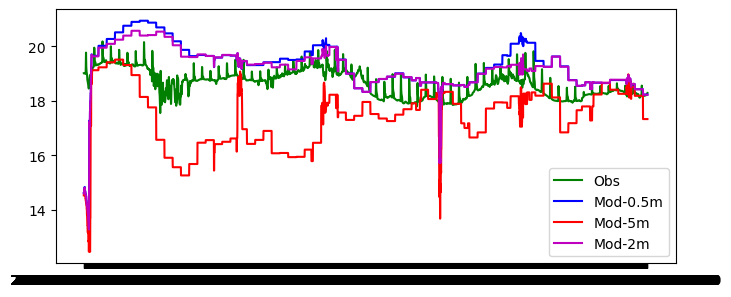

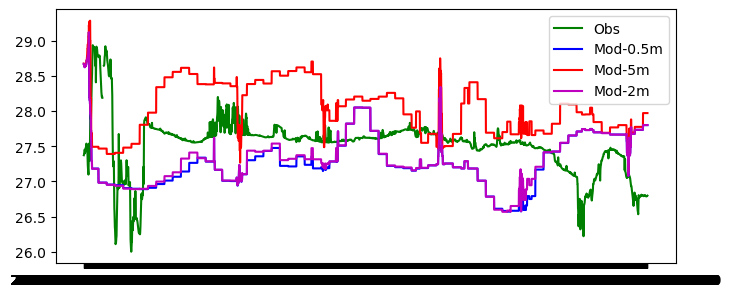

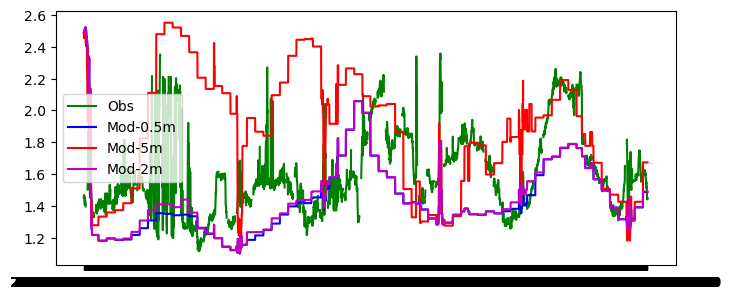

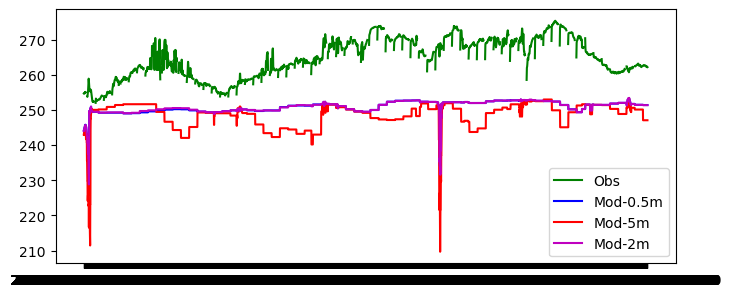

In [41]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(1,1,figsize = (8,3.3))
ax.plot(df['dtUTC'],df['SST'],'g',label='Obs')
ax.plot(df05['dtUTC'],df05['mod_votemper'],'b',label='Mod-0.5m')
ax.plot(df5['dtUTC'],df5['mod_votemper'],'r',label='Mod-5m')
ax.plot(df['dtUTC'],df['mod_votemper'],'m',label='Mod-2m')
ax.legend()

fig, ax = plt.subplots(1,1,figsize = (8,3.3))
ax.plot(df['dtUTC'],df['Sal'],'g',label='Obs')
ax.plot(df05['dtUTC'],df05['mod_vosaline'],'b',label='Mod-0.5m')
ax.plot(df5['dtUTC'],df5['mod_vosaline'],'r',label='Mod-5m')
ax.plot(df['dtUTC'],df['mod_vosaline'],'m',label='Mod-2m')
ax.legend()

fig, ax = plt.subplots(1,1,figsize = (8,3.3))
ax.plot(df['dtUTC'],df['Chl'],'g',label='Obs')
ax.plot(df05['dtUTC'],2.5*(df05['mod_diatoms']+df05['mod_flagellates']),'b',label='Mod-0.5m')
ax.plot(df5['dtUTC'],2.5*(df5['mod_diatoms']+df5['mod_flagellates']),'r',label='Mod-5m')
ax.plot(df['dtUTC'],2.5*(df['mod_diatoms']+df['mod_flagellates']),'m',label='Mod-2m')
ax.legend()

fig, ax = plt.subplots(1,1,figsize = (8,3.3))
#ax.plot(df['dtUTC'],df['O2_conc(µM)'])
ax.plot(df['dtUTC'],df['O2_corr'],'g',label='Obs')
ax.plot(df05['dtUTC'],df05['mod_dissolved_oxygen'],'b',label='Mod-0.5m')
ax.plot(df5['dtUTC'],df5['mod_dissolved_oxygen'],'r',label='Mod-5m')
ax.plot(df['dtUTC'],df['mod_dissolved_oxygen'],'m',label='Mod-2m')
ax.legend()
